In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import sys

from miscellaneous import read_instance

In [2]:
def load_results(filepath='results/optimization_results.csv'):
    df = pd.read_csv(filepath)
    df['landing_times'] = df['landing_times'].apply(ast.literal_eval)
    df['runway_assignment'] = df['runway_assignment'].apply(ast.literal_eval)
    return df

def get_instance_data(df, instance_number, number_of_runways, objective):
    row = df[
        (df['instance_number'] == instance_number) &
        (df['number_of_runways'] == number_of_runways) &
        (df['objective'] == objective)
    ].iloc[0]
    return row

# Load the data
df = load_results()

In [3]:
def plot_landing_schedule(instance_number, number_of_runways, objective):

    row = get_instance_data(df, instance_number, number_of_runways, objective)
    landing_times = row['landing_times']
    runway_assignment = row['runway_assignment']

    # ── Color palette (one distinct color per runway) ──────────────────────────
    cmap = plt.get_cmap('tab10')
    runway_colors = {r: cmap(r % 10) for r in range(number_of_runways)}

    # ── Figure setup ───────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, max(4, number_of_runways * 2.5)))
    fig.patch.set_facecolor('#F7F9FC')
    ax.set_facecolor('#F7F9FC')

    # ── Horizontal runway lanes (subtle background bands) ──────────────────────
    for r in range(number_of_runways):
        band_color = '#E8EDF3' if r % 2 == 0 else '#F7F9FC'
        ax.axhspan(r - 0.45, r + 0.45, color=band_color, zorder=0)

    # ── Timeline baseline per runway ───────────────────────────────────────────
    for r in range(number_of_runways):
        ax.axhline(y=r, color='#C0C8D2', linewidth=1, linestyle='--', zorder=1)

    # ── Plot each aircraft ─────────────────────────────────────────────────────
    for i, (time, runway) in enumerate(zip(landing_times, runway_assignment)):
        color = runway_colors[runway]

        # Outer ring
        ax.scatter(time, runway, s=320, color=color, alpha=0.25, zorder=3)
        # Filled dot
        ax.scatter(time, runway, s=140, color=color, edgecolors='white',
                linewidths=1.5, zorder=4)
        # Aircraft label
        ax.text(time, runway, str(i),
                ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white', zorder=5)

    # ── Axes styling ───────────────────────────────────────────────────────────
    ax.set_xlabel('Landing Time', fontsize=12, labelpad=8, color='#2C3E50')
    ax.set_ylabel('Runway', fontsize=12, labelpad=8, color='#2C3E50')
    ax.set_yticks(range(number_of_runways))
    ax.set_yticklabels([f'Runway {r}' for r in range(number_of_runways)],
                    fontsize=10, color='#2C3E50')
    ax.tick_params(axis='x', colors='#2C3E50', labelsize=9)
    ax.set_ylim(-0.6, number_of_runways - 0.4)

    # Remove top/right spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#C0C8D2')

    ax.grid(axis='x', color='#D5DCE6', linestyle=':', linewidth=0.8, zorder=0)

    # ── Title ──────────────────────────────────────────────────────────────────
    ax.set_title(
        f'Landing Schedule — Instance {instance_number} · '
        f'{number_of_runways} Runways · Objective: {objective}',
        fontsize=13, fontweight='bold', color='#1A252F', pad=14
    )

    plt.tight_layout()
    plt.savefig(f'results/plots/landing_schedule_instance_{instance_number}_runways_{number_of_runways}_objective_{objective}.png', dpi=300)
    plt.show()

In [4]:
def plot_feasibility_check(instance_number, number_of_runways, objective):

        row = get_instance_data(df, instance_number, number_of_runways, objective)
        landing_times = row['landing_times']
        runway_assignment = row['runway_assignment']  # Extract from the row

        # Import the function to read instance data
        sys.path.append('.')

        # Read the instance file for the current instance
        instance_data = read_instance(instance_number)

        # ── Color palette (one distinct color per runway) ──────────────────────────
        cmap = plt.get_cmap('tab10')
        runway_colors = {r: cmap(r % 10) for r in range(number_of_runways)}

        # Extract data for visualization
        n_aircraft = len(landing_times)
        target_times = [instance_data['target_landing_vector'][i] for i in range(n_aircraft)]
        earliest_times = [instance_data['earliest_landing_vector'][i] for i in range(n_aircraft)]
        latest_times = [instance_data['latest_landing_vector'][i] for i in range(n_aircraft)]
        actual_times = landing_times

        # Create the visualization
        fig, ax = plt.subplots(figsize=(14, max(8, n_aircraft * 0.6)))
        fig.patch.set_facecolor('#F7F9FC')
        ax.set_facecolor('#F7F9FC')

        # Plot for each aircraft
        for i in range(n_aircraft):
                y_pos = n_aircraft - i - 1  # Reverse order so aircraft 0 is at top
                
                # Time window (earliest to latest) as a horizontal bar
                ax.plot([earliest_times[i], latest_times[i]], [y_pos, y_pos], 
                                color='#D5DCE6', linewidth=8, solid_capstyle='round', zorder=1, alpha=0.6)
                
                # Target time marker
                ax.scatter(target_times[i], y_pos, s=150, marker='d', 
                                color='#3498db', edgecolors='white', linewidths=2, 
                                zorder=3, label='Target' if i == 0 else '')
                
                # Actual landing time marker
                runway_color = runway_colors[runway_assignment[i]]
                ax.scatter(actual_times[i], y_pos, s=200, marker='o', 
                                color=runway_color, edgecolors='white', linewidths=2, 
                                zorder=4, label='Actual' if i == 0 else '')
                
                # Earliest and latest markers
                ax.scatter(earliest_times[i], y_pos, s=80, marker='|', 
                                color='#7f8c8d', linewidths=3, zorder=2, 
                                label='Earliest/Latest' if i == 0 else '')
                ax.scatter(latest_times[i], y_pos, s=80, marker='|', 
                                color='#7f8c8d', linewidths=3, zorder=2)
                
                # Add aircraft label
                ax.text(earliest_times[i] - (latest_times[i] - earliest_times[i]) * 0.15, 
                                y_pos, f'Aircraft {i}', 
                                ha='right', va='center', fontsize=9, color='#2C3E50', fontweight='bold')

        # Styling
        ax.set_xlabel('Time', fontsize=12, labelpad=8, color='#2C3E50')
        ax.set_ylabel('Aircraft', fontsize=12, labelpad=8, color='#2C3E50')
        ax.set_yticks(range(n_aircraft))
        ax.set_yticklabels([])
        ax.set_ylim(-0.5, n_aircraft - 0.5)
        ax.tick_params(axis='x', colors='#2C3E50', labelsize=9)

        # Remove spines
        for spine in ['top', 'right', 'left']:
                ax.spines[spine].set_visible(False)
        ax.spines['bottom'].set_color('#C0C8D2')

        # Grid
        ax.grid(axis='x', color='#E8EDF3', linestyle='-', linewidth=0.8, zorder=0)

        # Legend
        ax.legend(loc='upper right', framealpha=0.95, fontsize=9)

        # Title
        ax.set_title(
                f'Aircraft Landing Schedule Details — Instance {instance_number} · '
                f'{number_of_runways} Runways · Objective: {objective}',
                fontsize=13, fontweight='bold', color='#1A252F', pad=14
        )

        plt.tight_layout()
        plt.savefig(f'results/plots/feasibility_check_instance_{instance_number}_runways_{number_of_runways}_objective_{objective}.png', dpi=300)
        plt.show()

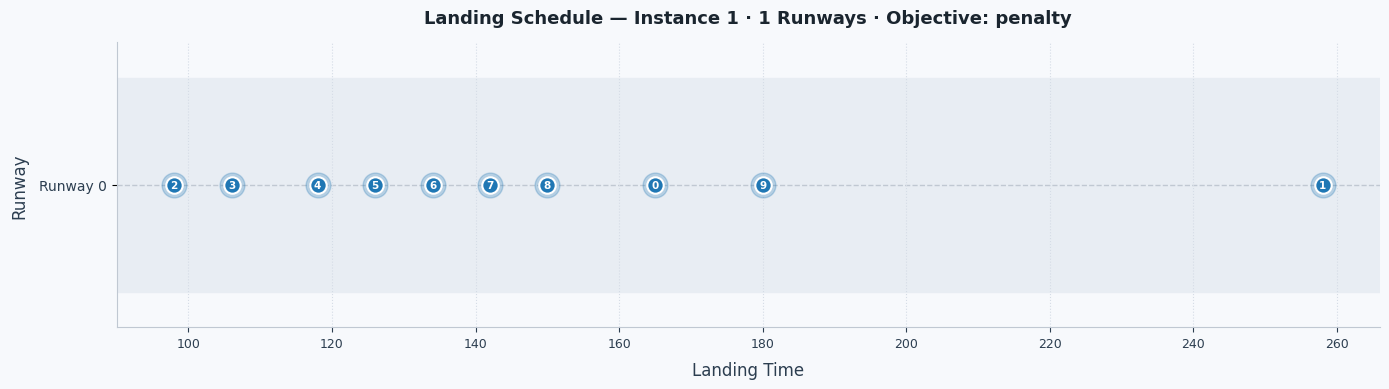

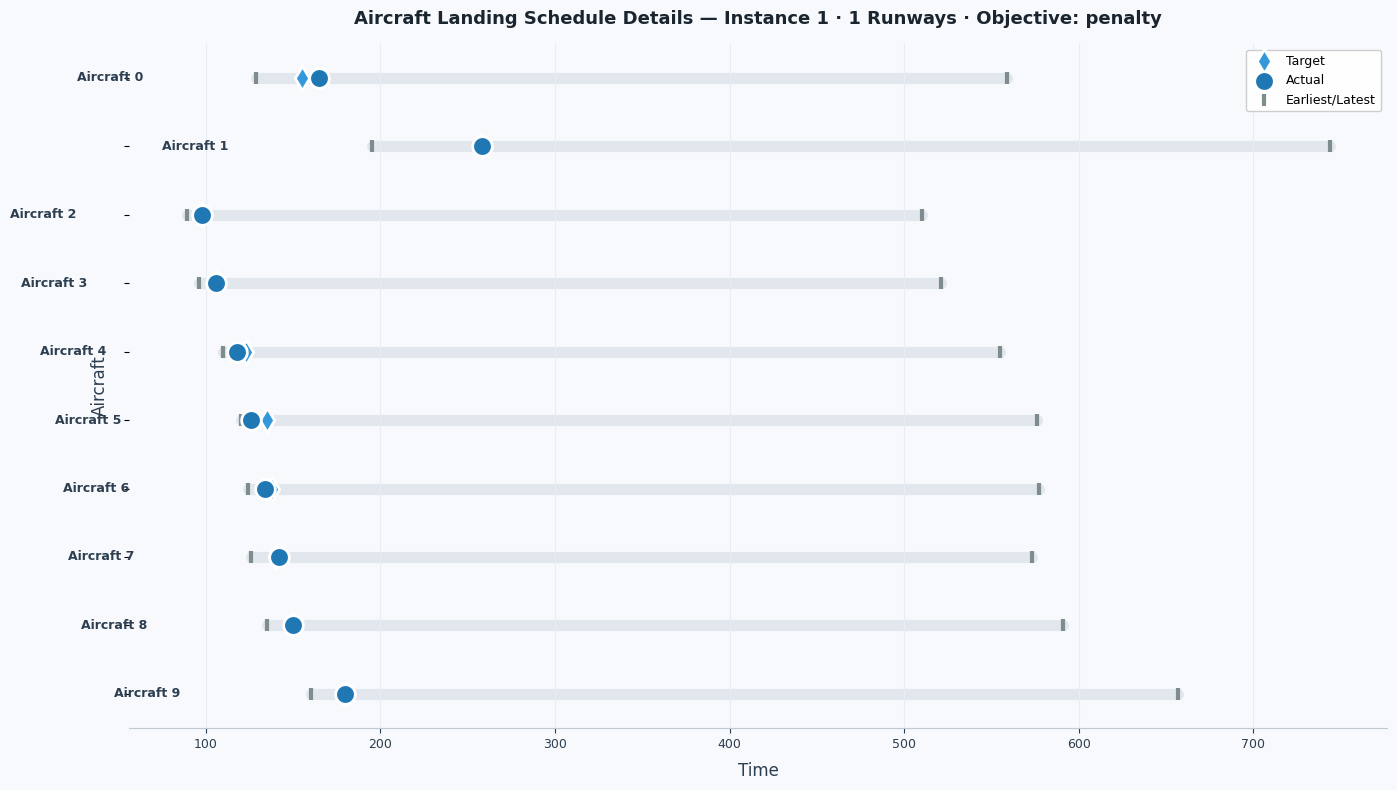

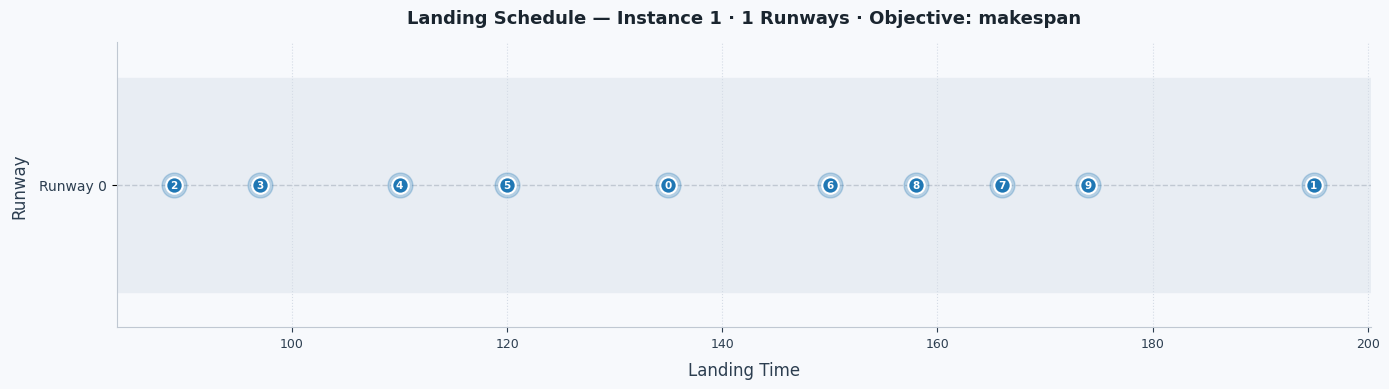

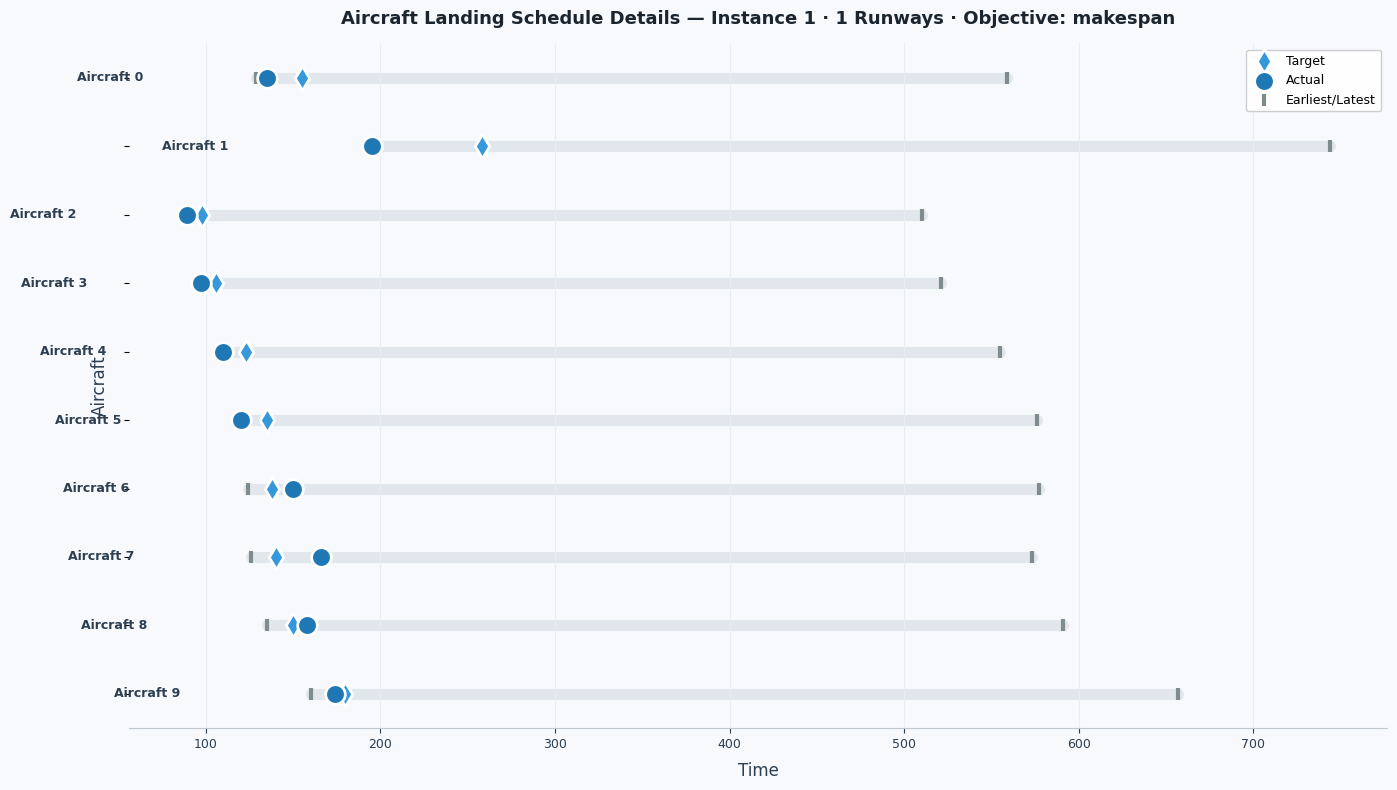

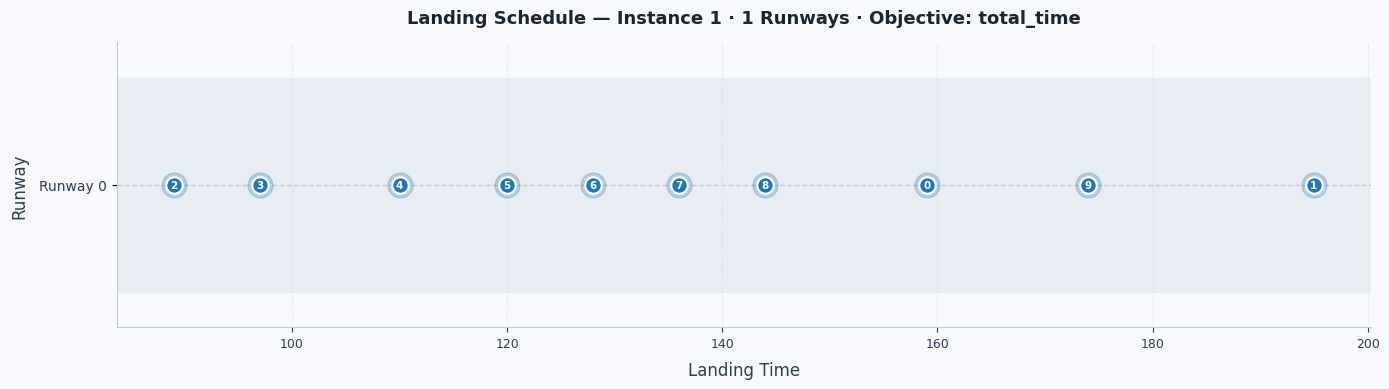

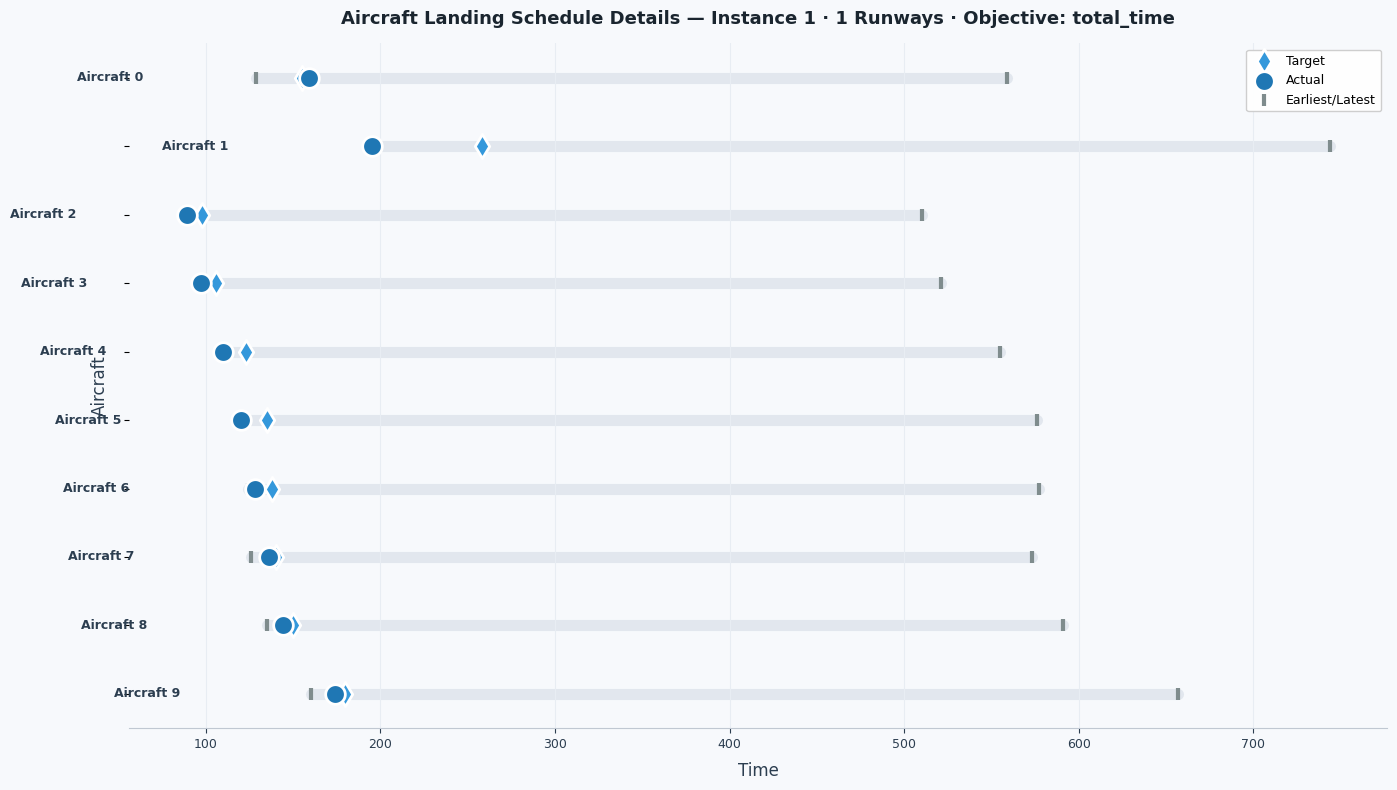

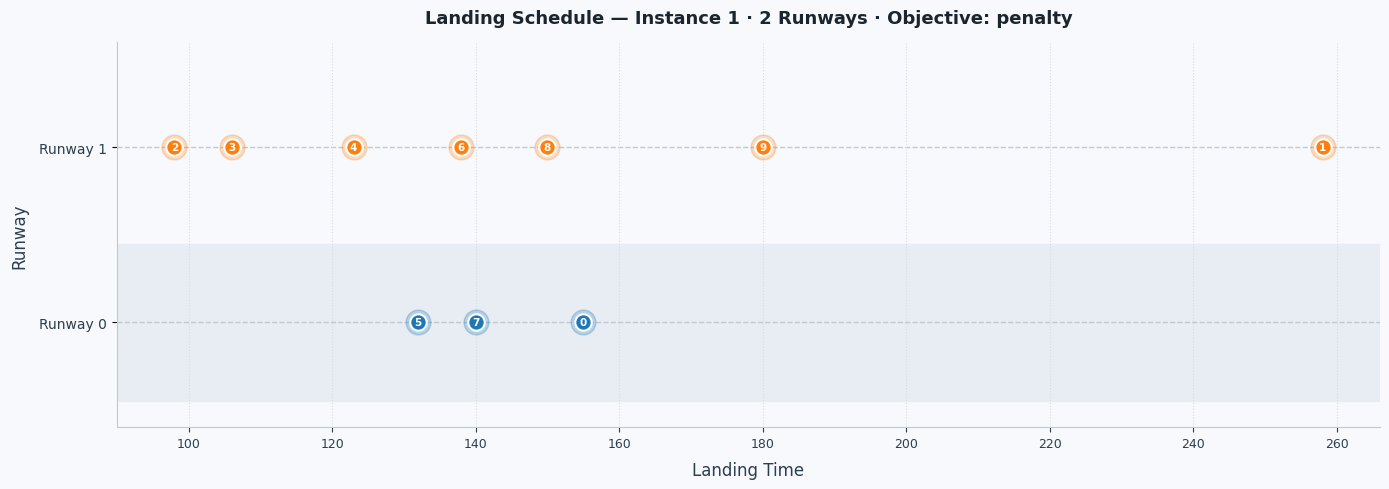

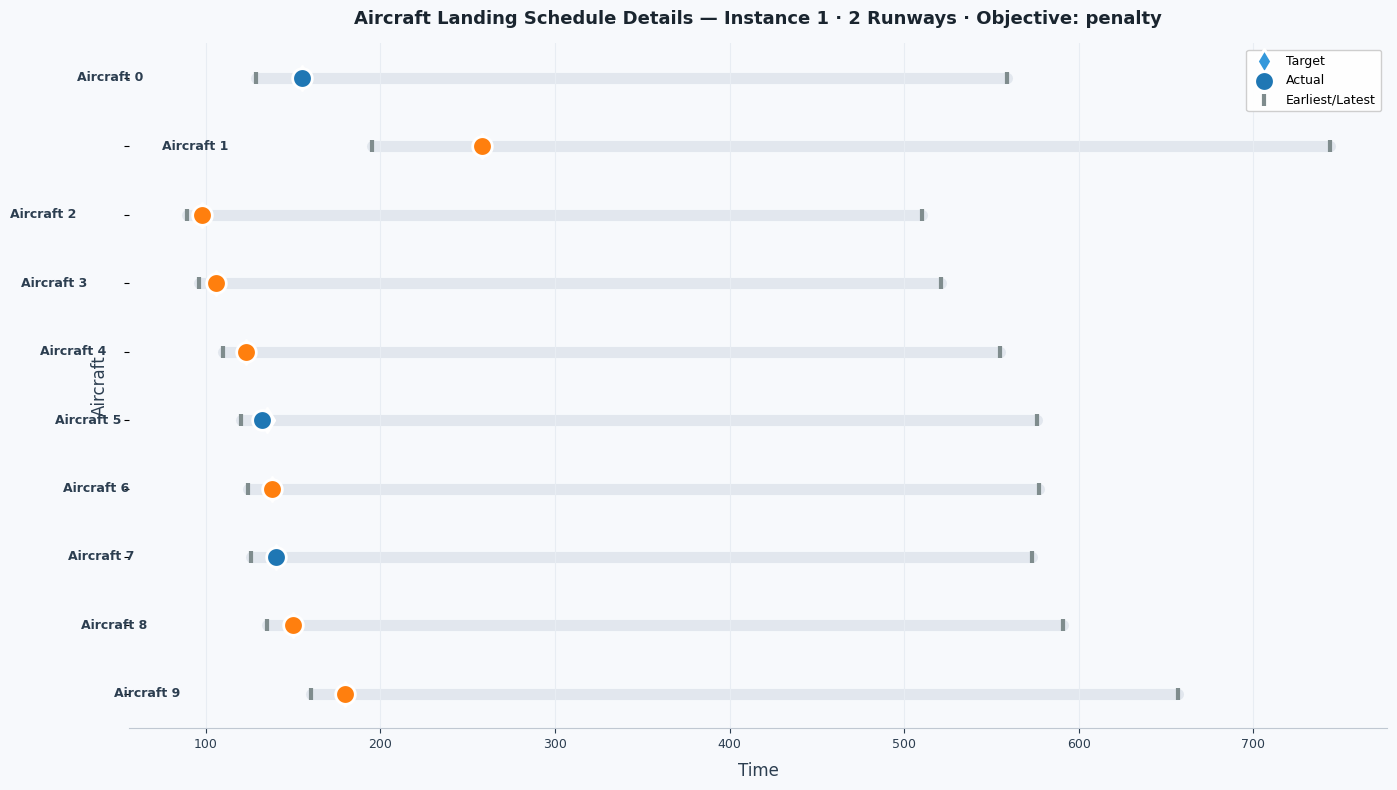

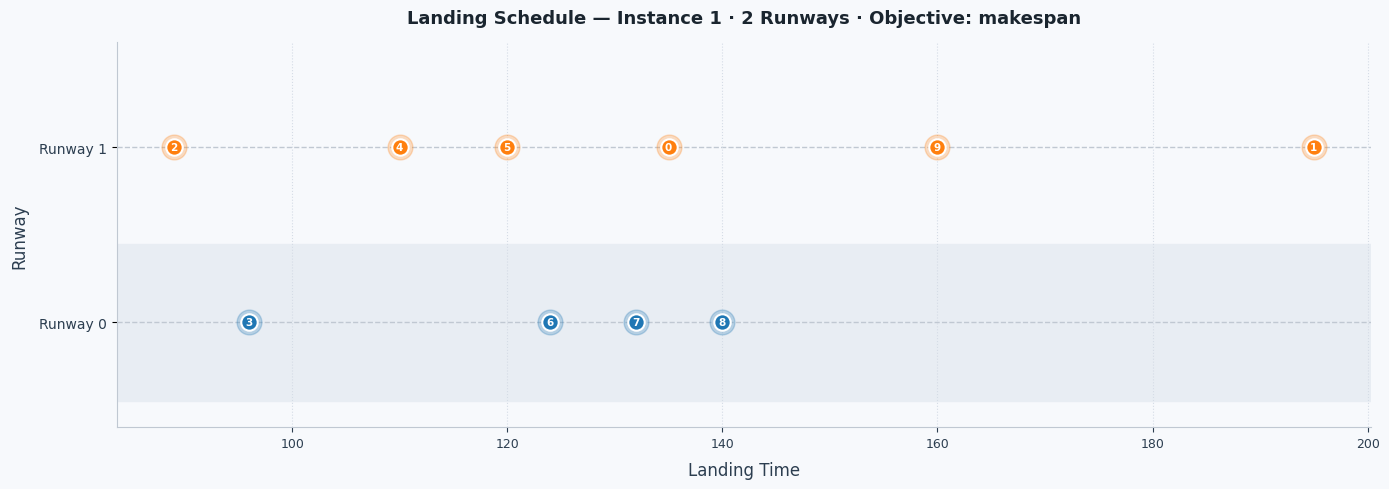

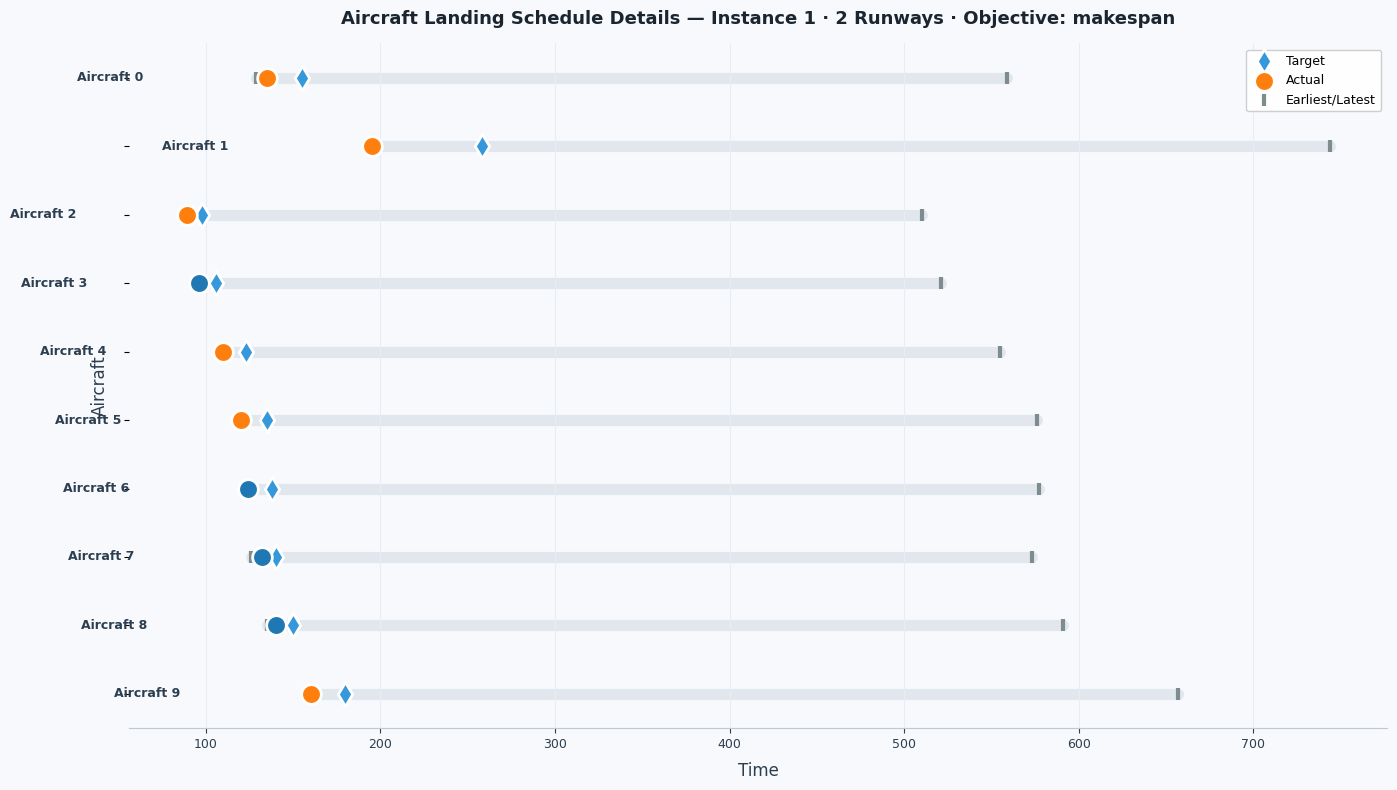

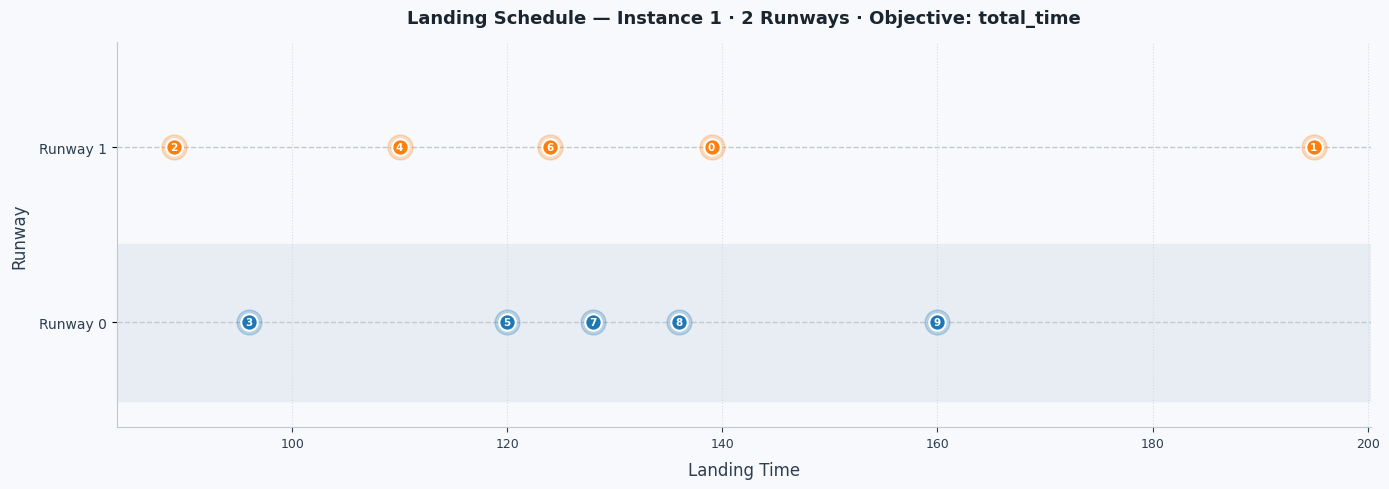

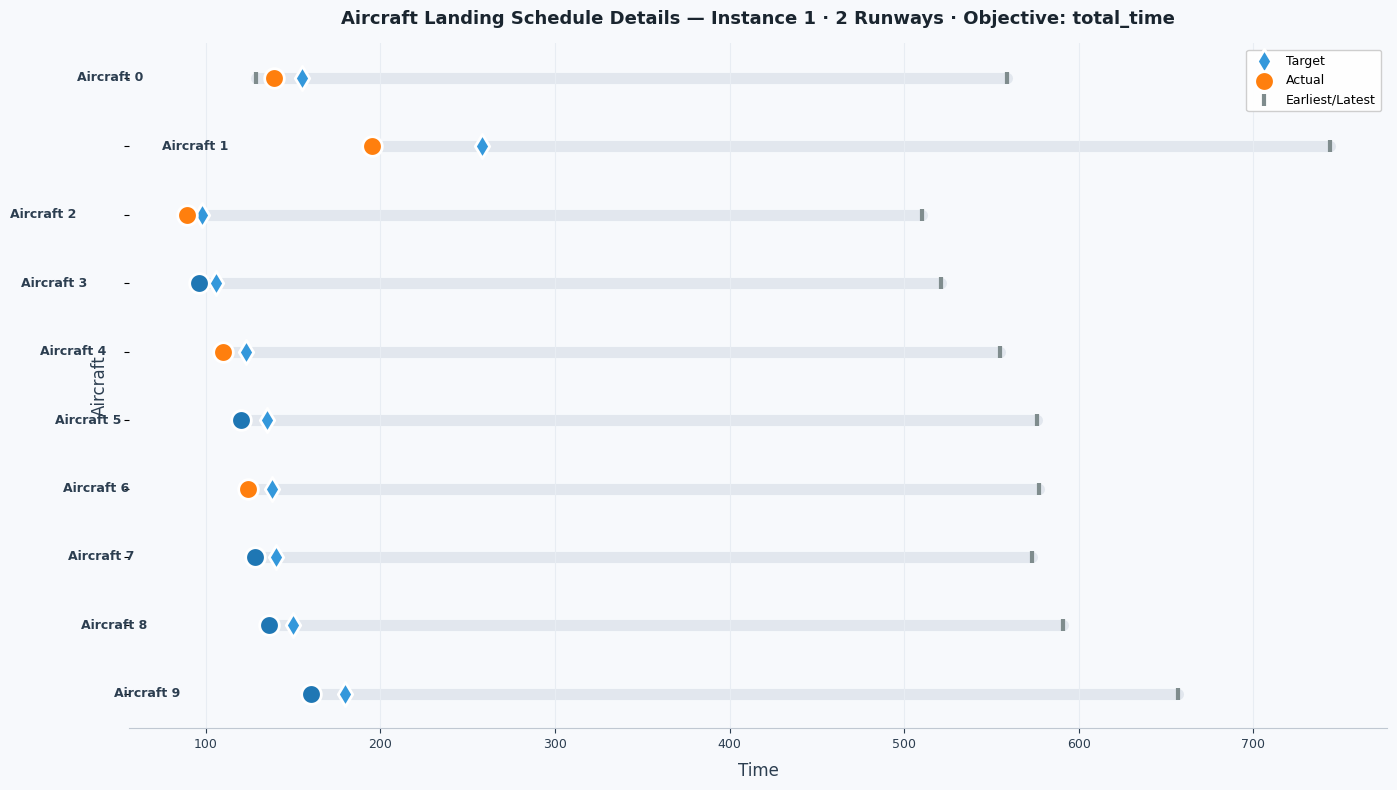

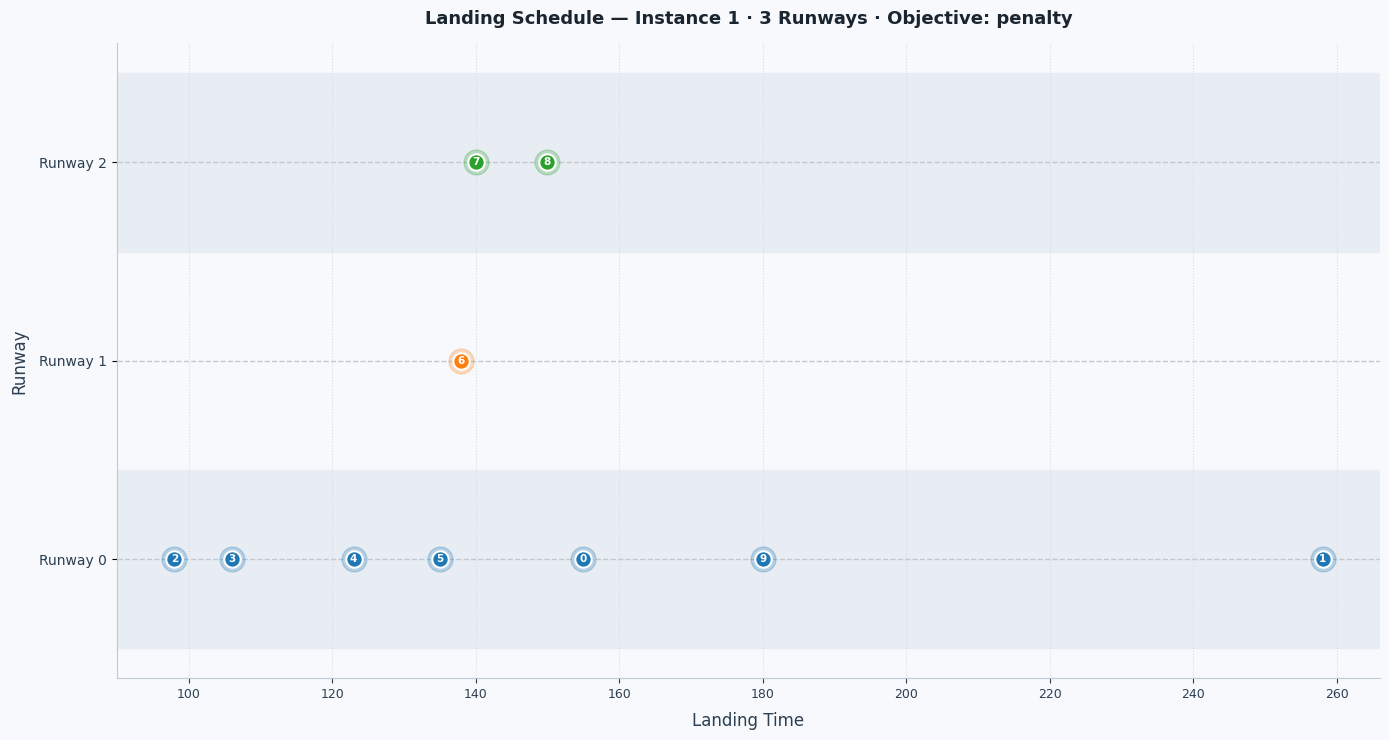

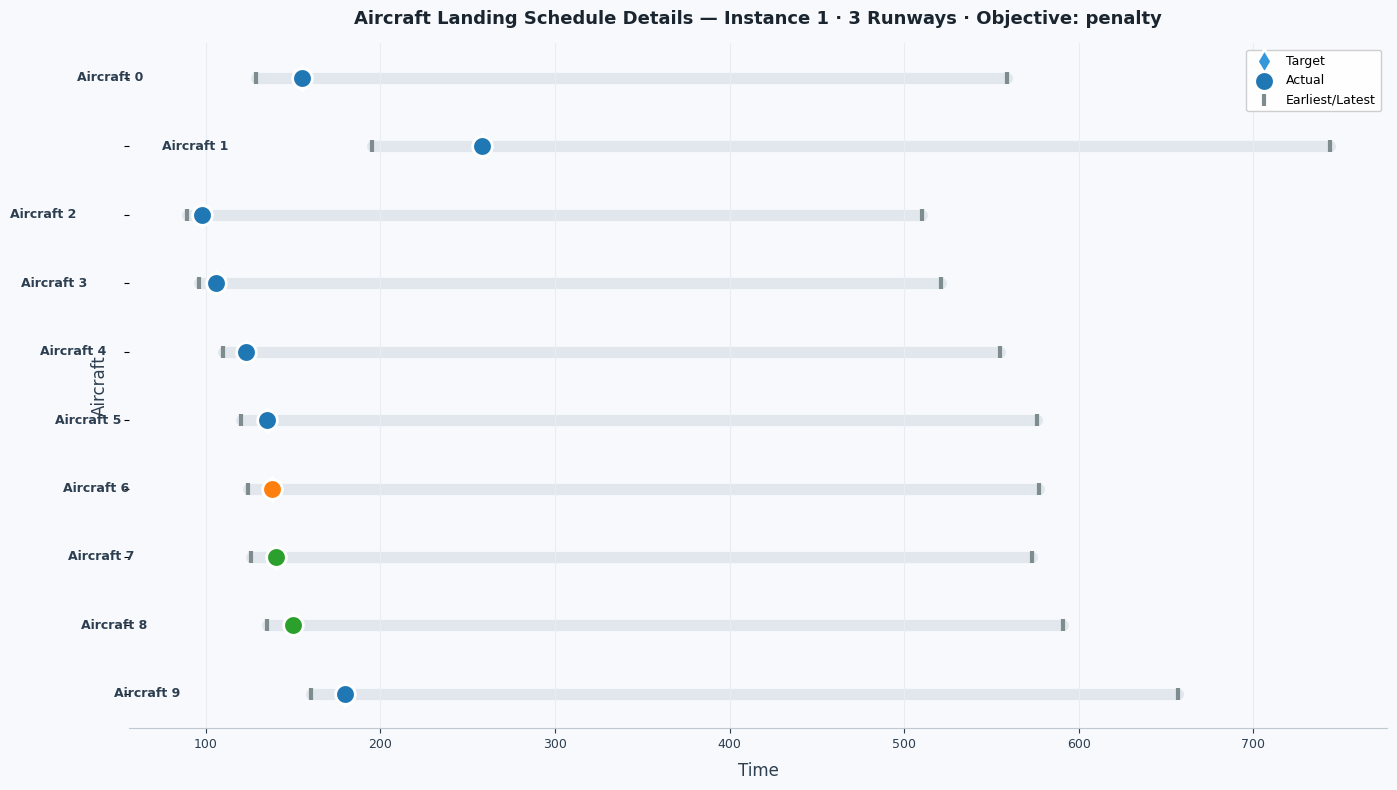

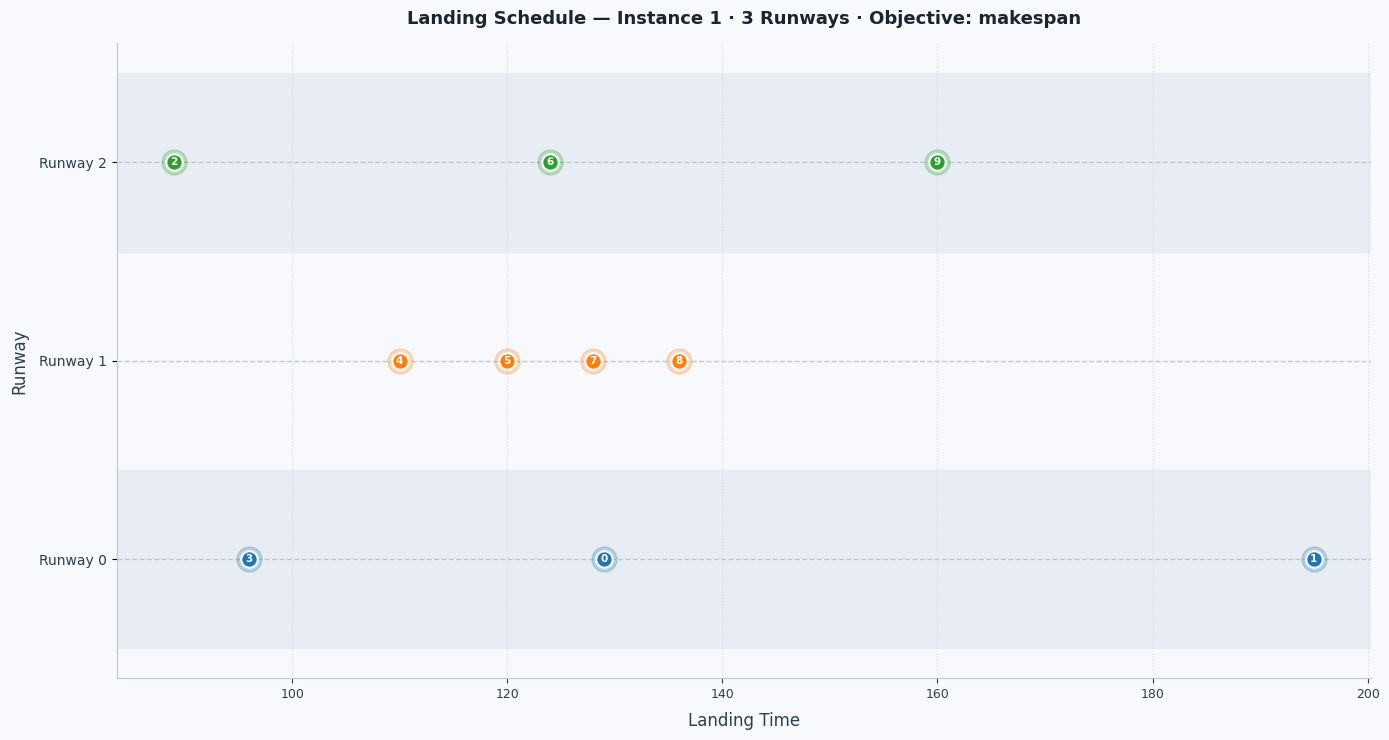

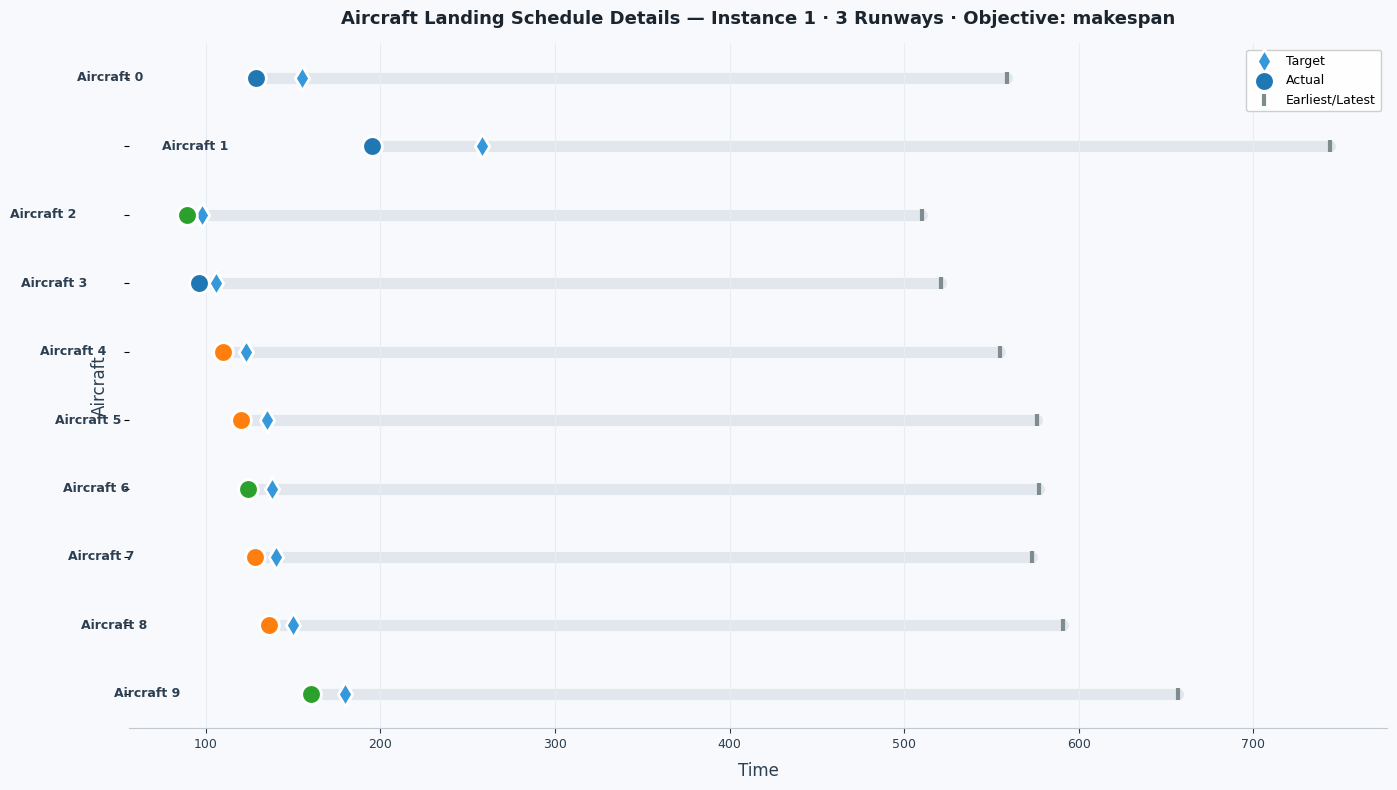

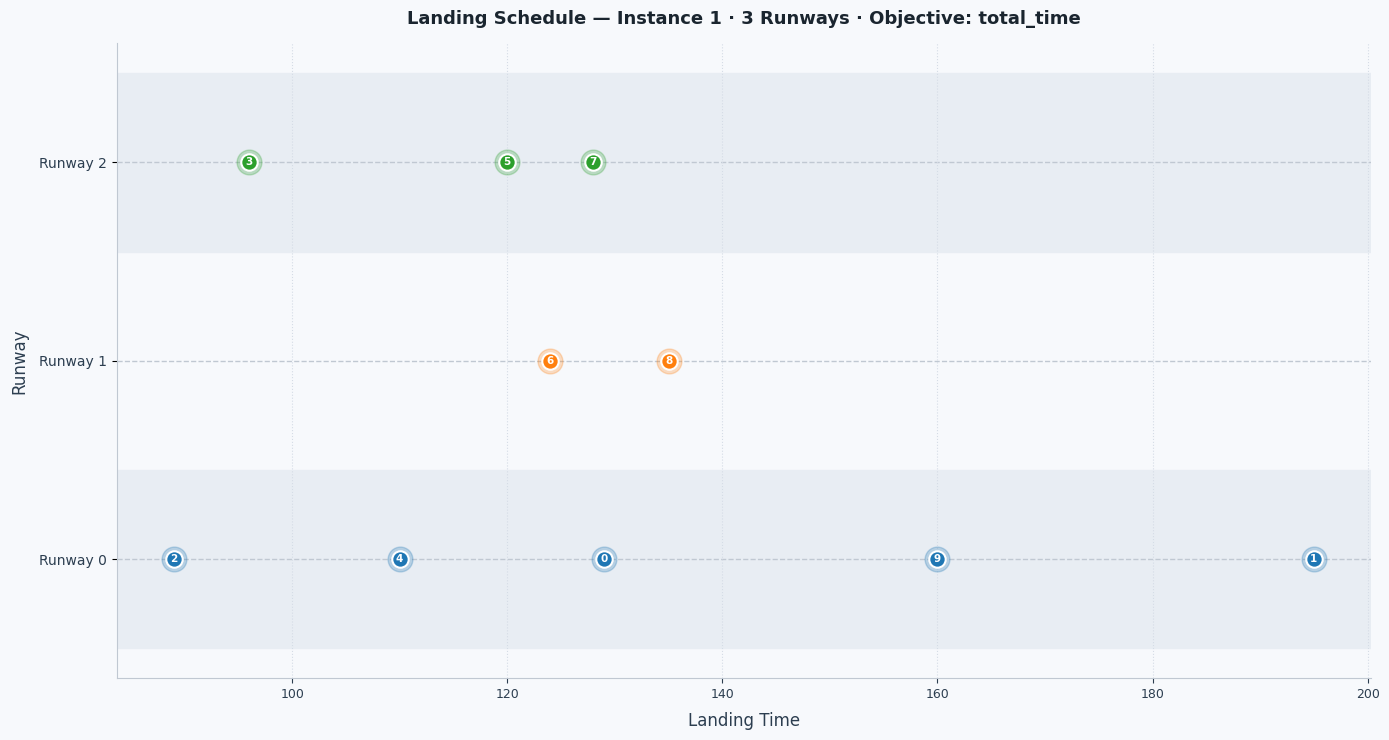

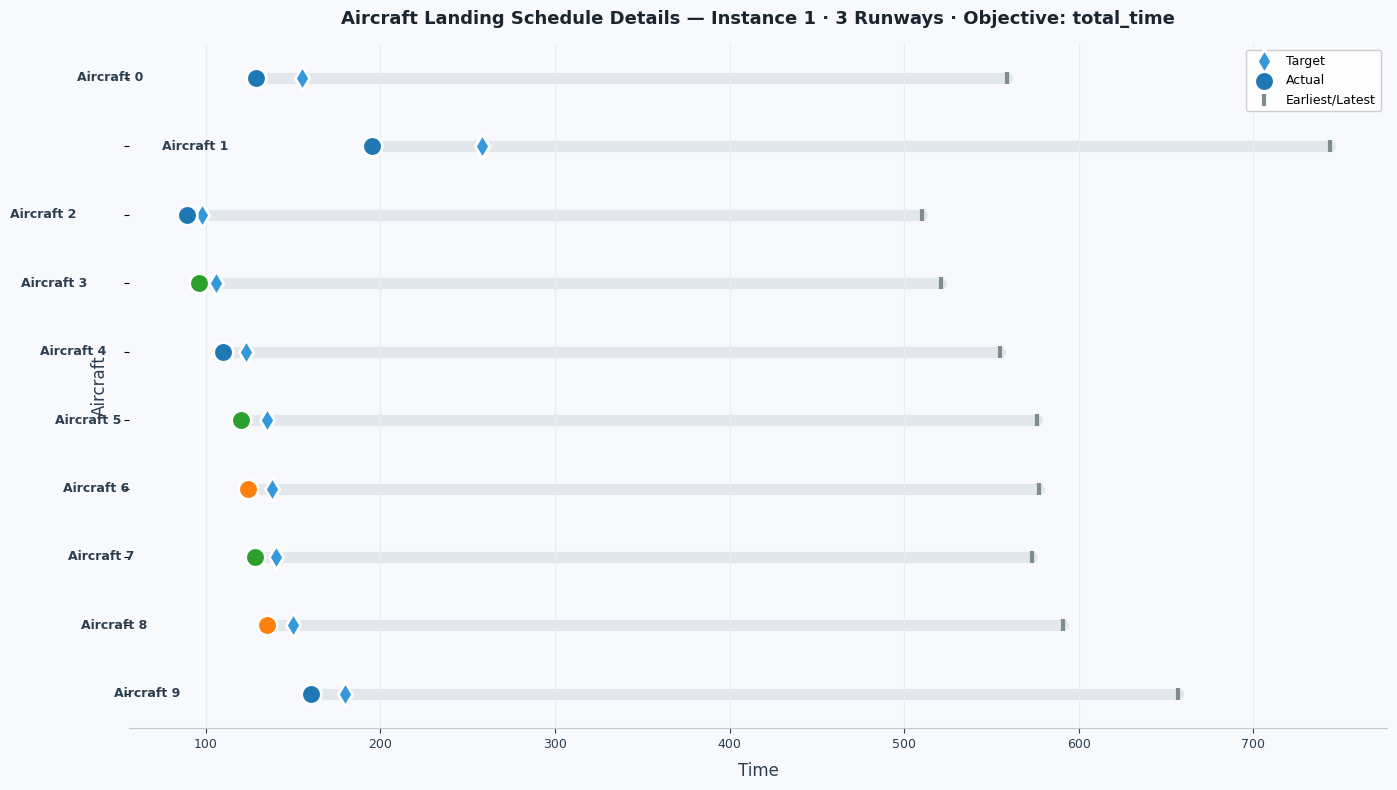

In [5]:
instance_numbers = [1]
number_of_runways_list = [1, 2, 3]
objectives = ['penalty', 'makespan', 'total_time']

for instance_number in instance_numbers:
    for number_of_runways in number_of_runways_list:
        for objective in objectives:
            plot_landing_schedule(instance_number, number_of_runways, objective)
            plot_feasibility_check(instance_number, number_of_runways, objective)